# 评估同化算法的性能


In [1]:
%load_ext autoreload
%autoreload 2

## 基本参数设置

In [2]:
# Depending on your combination of package versions, this can raise a lot of TF warnings... 
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import xarray as xr
# import torch
# import seaborn as sns
from pathlib import Path
import pickle
import sys 
sys.path.append('../')

In [3]:
!ls /public/home/wangwuxing01/research/fundation/output

da_cycle  forecast  medium_forecast


In [4]:
da_cycle_dir = "/public/home/wangwuxing01/research/fundation/output/da_cycle"
medium_forecast_dir = "/public/home/wangwuxing01/research/fundation/output/medium_forecast"
scaler_dir = "/public/home/wangwuxing01/research/fundation/data/era5_6_hourly/assim_dir_3day/scaler.pkl"
var_idx_dir = "/public/home/wangwuxing01/research/fundation/data/era5_6_hourly/assim_dir_3day/var_idx.npy"

In [5]:
var_idx = [k for k in np.load(var_idx_dir)]

In [6]:
plot_vars = ["Z", "T", "R", "U"]
unit_y = ["(m$^2$ s$^{-2}$)", "(K)", "(%)", "(m s$^{-1}$)"]
plot_idx = [1, 10, 22, 20, 21, 23, 9, 5, 13, 17]

In [7]:
tmp = xr.open_mfdataset("/public/home/wangwuxing01/research/fundation/data/era5_6_hourly/obs_r_2010.nc", 
                  combine="by_coords", parallel=True)

In [8]:
lat, lon = tmp.latitude.values, tmp.longitude.values

In [9]:
idx = 35

In [10]:
xb_dacycle_4dvarnet = np.load(f"{da_cycle_dir}/xb_4dvarnet_obs[20, 21]_xb_3day_single.npy")[idx]
xb_dacycle_vit = np.load(f"{da_cycle_dir}/xb_vit_obs[20, 21]_xb_3day_single.npy")[idx]
xb_dacycle_4dvarformer = np.load(f"{da_cycle_dir}/xb_4dvarformer_obs[20, 21]_xb_3day_single.npy")[idx]

xa_dacycle_4dvarnet = np.load(f"{da_cycle_dir}/assim_4dvarnet_obs[20, 21]_xb_3day_single.npy")[idx, 0]
xa_dacycle_vit = np.load(f"{da_cycle_dir}/assim_vit_obs[20, 21]_xb_3day_single.npy")[idx, 0]
xa_dacycle_4dvarformer = np.load(f"{da_cycle_dir}/assim_4dvarformer_obs[20, 21]_xb_3day_single.npy")[idx, 0]

xt = np.load(f"{da_cycle_dir}/real_xb_3day.npy")[idx, 0]

In [11]:
diff = xb_dacycle_4dvarnet - xt
dx_4dvarnet = xa_dacycle_4dvarnet - xb_dacycle_4dvarnet
dx_vit = xa_dacycle_vit - xb_dacycle_vit
dx_4dvarformer = xa_dacycle_4dvarformer - xb_dacycle_4dvarformer

In [12]:
z50 = [diff[0], dx_4dvarnet[0], dx_vit[0], dx_4dvarformer[0], xt[0]]
z500 = [diff[1], dx_4dvarnet[1], dx_vit[1], dx_4dvarformer[1], xt[1]]
z850 = [diff[2], dx_4dvarnet[2], dx_vit[2], dx_4dvarformer[2], xt[2]]
z1000 = [diff[3], dx_4dvarnet[3], dx_vit[3], dx_4dvarformer[3], xt[3]]
msl = [diff[23], dx_4dvarnet[23], dx_vit[23], dx_4dvarformer[23], xt[23]]
u10 = [diff[20], dx_4dvarnet[20], dx_vit[20], dx_4dvarformer[20], xt[20]]
v10 = [diff[21], dx_4dvarnet[21], dx_vit[21], dx_4dvarformer[21], xt[21]]
vis = [z50, z500, z850, z1000, msl, u10, v10]

In [13]:
titles = ["Background - ERA5", "4DVarNet", "Vit", "4DVarFormer", "ERA5 (ground truth)"]
ylables = ["50hPa geopotential (m$^2$ s$^{-2}$)", 
           "500hPa geopotential (m$^2$ s$^{-2}$)", 
           "850hPa geopotential (m$^2$ s$^{-2}$)", 
           "1000hPa geopotential (m$^2$ s$^{-2}$)", 
           "mean sea-level pressure (Pa)", 
           "u-component of 10-m wind (m s$^{-1}$)", 
           "v-component of 10-m wind (m s$^{-1}$)"]

In [14]:
vlim = [[-600, 600], [-500, 500], [-800, 800], [-1000, 1000], [-1000, 1000], [-15, 15], [-25, 25]]

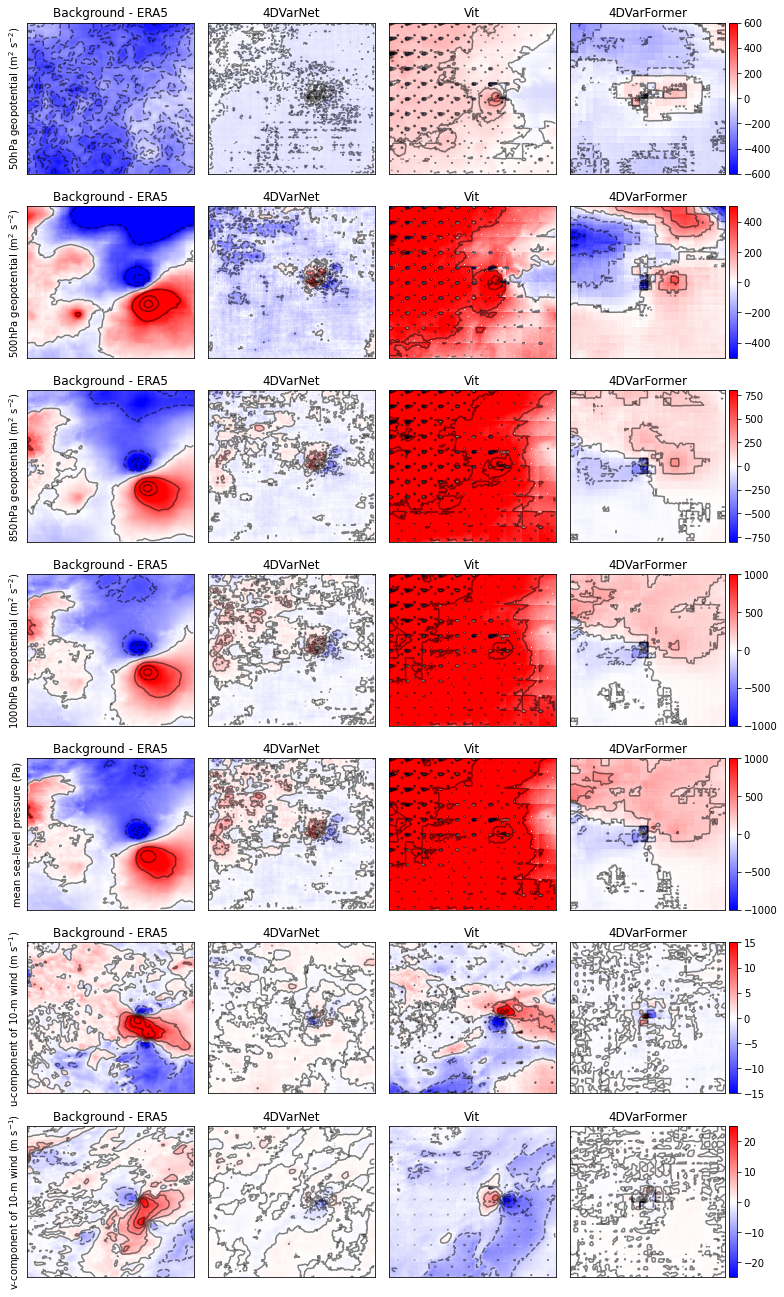

In [15]:
fig, axes = plt.subplots(7, 4, figsize=(11, 18))
for i in range(7):
    for j in range(4):
        axes[i, j].set_title(titles[j])
        im = axes[i, j].pcolormesh(lon[:-1], lat[:-1], vis[i][j], cmap="bwr", vmin=vlim[i][0], vmax=vlim[i][1])
        axes[i, j].contour(lon[:-1], lat[:-1], vis[i][j], colors="black", alpha=0.5)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        if j in np.arange(0, 25, 4):
            label = axes[i, j].set_ylabel(ylables[i])
        if j in np.arange(3, 25, 4):
            divider = make_axes_locatable(axes[i, j])
            cax = divider.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im, cax=cax)
                    
plt.tight_layout()
plt.savefig(f'increment_wind_single.jpg',dpi=300)
plt.show()

In [16]:
r50 = [dx_4dvarnet[4], dx_vit[4], dx_4dvarformer[4], xt[4]]
r500 = [dx_4dvarnet[5], dx_vit[5], dx_4dvarformer[5], xt[5]]
r850 = [dx_4dvarnet[6], dx_vit[6], dx_4dvarformer[6], xt[6]]
r1000 = [dx_4dvarnet[7], dx_vit[7], dx_4dvarformer[7], xt[7]]
t50 = [dx_4dvarnet[8], dx_vit[8], dx_4dvarformer[8], xt[8]]
t500 = [dx_4dvarnet[9], dx_vit[9], dx_4dvarformer[9], xt[9]]
t850 = [dx_4dvarnet[10], dx_vit[10], dx_4dvarformer[10], xt[10]]
t1000 = [dx_4dvarnet[11], dx_vit[11], dx_4dvarformer[11], xt[11]]
t2m = [dx_4dvarnet[22], dx_vit[22], dx_4dvarformer[22], xt[22]]
vis_r = [r50, r500, r850, r1000]
vis_t = [t50, t500, t850, t1000, t2m]

In [17]:
titles = ["4DVarNet", "Vit", "4DVarFormer", "ERA5 (ground truth)"]
ylables = ["50hPa relative humidity (%)", "500hPa relative humidity (%)", 
           "850hPa relative humidity (%)", "1000hPa relative humidity (%)"]

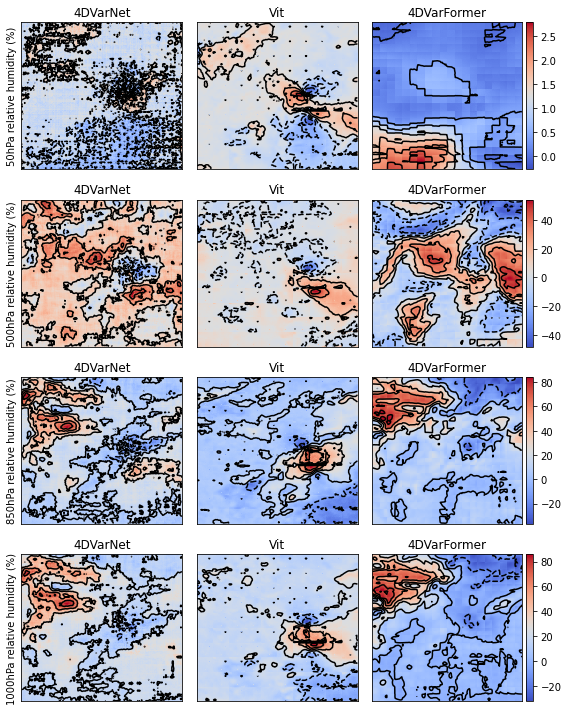

In [50]:
fig, axes = plt.subplots(4, 3, figsize=(8, 10))
for i in range(4):
    for j in range(3):
        axes[i, j].set_title(titles[j])
        im = axes[i, j].pcolormesh(lon[:-1], lat[:-1], vis_r[i][j], cmap="coolwarm")
        axes[i, j].contour(lon[:-1], lat[:-1], vis_r[i][j], colors="black")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        if j in [0, 3, 6, 9, 12, 15, 18]:
            label = axes[i, j].set_ylabel(ylables[i])
        if j in [2, 5, 8, 11, 14, 17, 20]:
            divider = make_axes_locatable(axes[i, j])
            cax = divider.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im, cax=cax)
                    
plt.tight_layout()
plt.savefig(f'increment_temp_rh.jpg',dpi=300)
plt.show()

In [53]:
titles = ["4DVarNet", "Vit", "4DVarFormer", "ERA5 (ground truth)"]
ylables = ["50hPa temperature (K)", "500hPa temperature (K)", 
           "850hPa temperature (K)", "1000hPa temperature (K)", "2-m temperature (K)"]

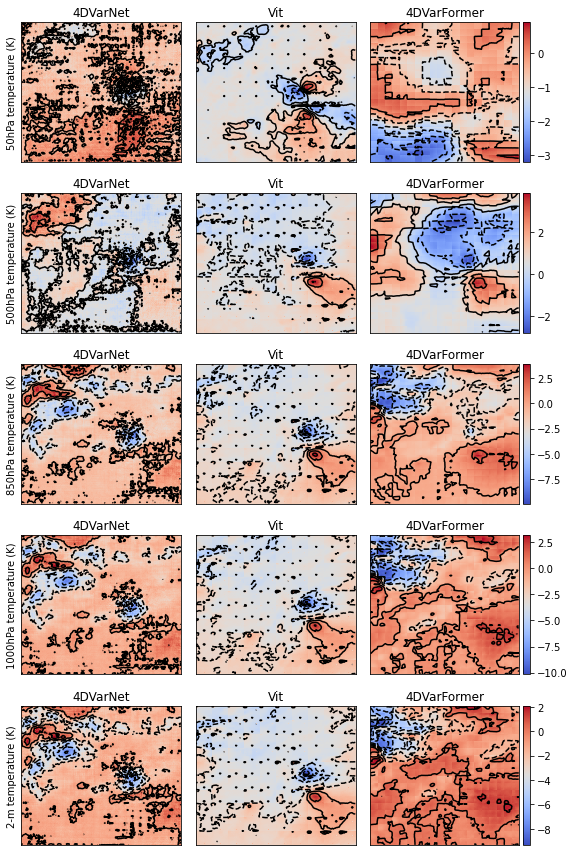

In [54]:
fig, axes = plt.subplots(5, 3, figsize=(8, 12))
for i in range(5):
    for j in range(3):
        axes[i, j].set_title(titles[j])
        im = axes[i, j].pcolormesh(lon[:-1], lat[:-1], vis_t[i][j], cmap="coolwarm")
        axes[i, j].contour(lon[:-1], lat[:-1], vis_t[i][j], colors="black")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        if j in [0, 3, 6, 9, 12, 15, 18]:
            label = axes[i, j].set_ylabel(ylables[i])
        if j in [2, 5, 8, 11, 14, 17, 20]:
            divider = make_axes_locatable(axes[i, j])
            cax = divider.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im, cax=cax)
                    
plt.tight_layout()
plt.savefig(f'increment_temp.jpg',dpi=300)
plt.show()